In [5]:
!pip install pandas numpy matplotlib seaborn scikit-learn tensorflow

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.2.3-py3-none-any.whl.metadata (5.0 kB)
  Using cached joblib-1.5.1-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached absl_py-2.3.1-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.2.10-py2.py3-none-any.whl.metadata (875 bytes)
  Using cached gast-0.6.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-1-py2.py3-none-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached requests-2.32.4-py3-none-an

--- Loading Real Data ---
Successfully loaded the dataset.

--- Preprocessing and Feature Engineering for All Cities ---
Engineered features created for the entire dataset.

--- Scaling Global Data and Creating Sequences ---
Shape of input sequences (X): (161, 4, 7)
Shape of output values (y): (161,)

--- Building and Training the Global Model ---
Epoch 1/200


/Users/madhusudanmahatha/groundwater_prediction_project/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0801
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0337 
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0259 
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0196 
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0140 
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0065 
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0038 
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0040 
Epoch 9/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0049 
Epoch 10/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0031 
Epoch 11/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0015     
Epoch 12/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0023 
Epoch 13/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0019 
Epoch 14/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0014 
Epoch 15/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0015 
Epoch 16/200
6/6 ━━━━━━━━━━━


--- Saving the Global Model and Scaler ---
Global model saved to: ../models/global_model.h5
Global scaler saved to: ../models/global_scaler.pkl

--- Generating Example 5-Year Forecast for Kolkata ---


/Users/madhusudanmahatha/groundwater_prediction_project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/Users/madhusudanmahatha/groundwater_prediction_project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/Users/madhusudanmahatha/groundwater_prediction_project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/Users/madhusudanmahatha/groundwater_prediction_project/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/Users/madhusudanmahatha/groundwater_predict

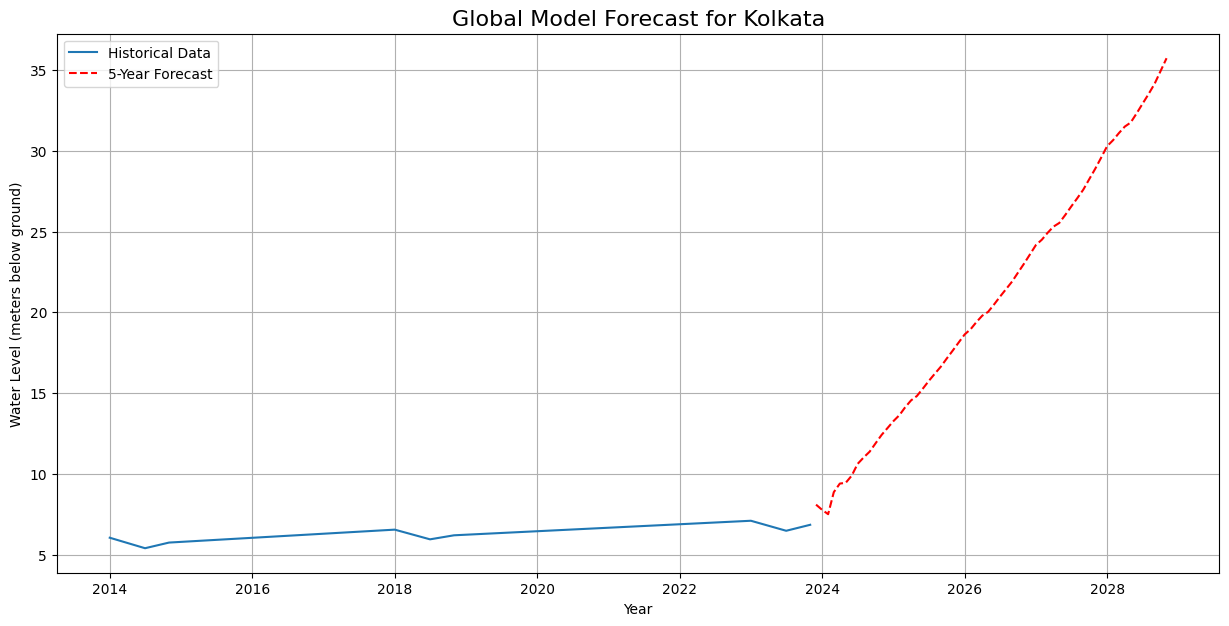

In [8]:

import pandas as pd
import numpy as np
import os
import pickle
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# --- 1. Load the Dataset ---
print("--- Loading Real Data ---")
data_file_path = '../data/City_Data - add major cities of west bengal , jharkhand and up.csv'

try:
    df = pd.read_csv(data_file_path)
    print("Successfully loaded the dataset.")
except FileNotFoundError:
    print(f"ERROR: The file was not found at {data_file_path}")
    exit()

# --- 2. Data Preparation and Feature Engineering ---
print("\n--- Preprocessing and Feature Engineering for All Cities ---")
df['date'] = pd.to_datetime(df['date'])
df.sort_values(['city', 'date'], inplace=True)

df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year
df['rainfall_lag_1'] = df.groupby('city')['monthly_rainfall_mm'].shift(1)
print("Engineered features created for the entire dataset.")

features = [
    'groundwater_level_mbgl', 'monthly_rainfall_mm', 'monthly_avg_temp_c',
    'estimated_population', 'month', 'year', 'rainfall_lag_1'
]
df_processed = df[['city'] + features].copy() # Keep 'city' for grouping

df_processed.ffill(inplace=True)
df_processed.bfill(inplace=True)

# --- 3. Scale Data and Create Sequences (Improved Method) ---
print("\n--- Scaling Global Data and Creating Sequences ---")
scaler = MinMaxScaler(feature_range=(0, 1))
# Fit the scaler on the feature data only (excluding the city column)
scaled_features = scaler.fit_transform(df_processed[features])

# Create a new dataframe with scaled features
df_scaled = pd.DataFrame(scaled_features, columns=features)
df_scaled['city'] = df_processed['city'].values

# --- ACCURACY IMPROVEMENT: Create sequences per city to prevent data leakage ---
def create_sequences_by_group(df_group, sequence_length):
    sequences = []
    data = df_group.values
    for i in range(len(data) - sequence_length):
        sequences.append(data[i:(i + sequence_length + 1)])
    return np.array(sequences)

SEQUENCE_LENGTH = 4
# Group by city, create sequences for each, and then combine them
all_sequences = df_scaled.groupby('city')[features].apply(
    lambda x: create_sequences_by_group(x, SEQUENCE_LENGTH)
)
# Concatenate all sequences into a single numpy array
all_sequences = np.concatenate(all_sequences.values)

# Split sequences into X (inputs) and y (target)
X = all_sequences[:, :-1, :]
y = all_sequences[:, -1, 0] # Target is the last step's groundwater level

print("Shape of input sequences (X):", X.shape)
print("Shape of output values (y):", y.shape)

# --- 4. Build and Train the GLOBAL Model ---
print("\n--- Building and Training the Global Model ---")
model = Sequential([
    LSTM(100, return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
    Dropout(0.2),
    LSTM(100, return_sequences=False),
    Dropout(0.2),
    Dense(50),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
early_stopping = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

model.fit(X, y, epochs=200, batch_size=32, verbose=1, callbacks=[early_stopping])

# --- 5. Save the GLOBAL Model and Scaler ---
print("\n--- Saving the Global Model and Scaler ---")
model_dir = '../models'
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

model_path = os.path.join(model_dir, "global_model.h5")
model.save(model_path)
print(f"Global model saved to: {model_path}")

scaler_path = os.path.join(model_dir, "global_scaler.pkl")
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"Global scaler saved to: {scaler_path}")

# --- 6. Example Forecast for a Specific City (Kolkata) ---
print("\n--- Generating Example 5-Year Forecast for Kolkata ---")
TARGET_CITY = 'Kolkata'
city_df = df[df['city'] == TARGET_CITY].copy()

# Re-process just this city's data to get its last sequence
city_df['month'] = city_df['date'].dt.month
city_df['year'] = city_df['date'].dt.year
city_df['rainfall_lag_1'] = city_df['monthly_rainfall_mm'].shift(1)
city_df.set_index('date', inplace=True)
city_df = city_df[features]
city_df.ffill(inplace=True)
city_df.bfill(inplace=True)

city_scaled_data = scaler.transform(city_df)
last_sequence = city_scaled_data[-SEQUENCE_LENGTH:]
current_sequence = last_sequence.reshape(1, SEQUENCE_LENGTH, len(features))

forecast = []
last_known_values = city_df.iloc[-1]
future_population = last_known_values['estimated_population']
population_growth = 0.015
last_date = city_df.index[-1]

for i in range(60): # 5 years
    next_step_pred_scaled = model.predict(current_sequence, verbose=0)[0, 0]
    forecast.append(next_step_pred_scaled)

    future_population *= (1 + (population_growth / 12))
    future_date = last_date + pd.DateOffset(months=i+1)
    
    new_row_unscaled = np.array([
        0, last_known_values['monthly_rainfall_mm'], last_known_values['monthly_avg_temp_c'],
        future_population, future_date.month, future_date.year, last_known_values['rainfall_lag_1']
    ]).reshape(1, -1)

    new_row_scaled_full = scaler.transform(new_row_unscaled)
    new_row_scaled_full[0, 0] = next_step_pred_scaled

    new_sequence = np.append(current_sequence[0][1:], new_row_scaled_full, axis=0)
    current_sequence = new_sequence.reshape(1, SEQUENCE_LENGTH, len(features))

dummy_array = np.zeros((len(forecast), len(features)))
dummy_array[:, 0] = forecast
forecast_actual = scaler.inverse_transform(dummy_array)[:, 0]

future_dates = pd.date_range(start=last_date, periods=61, freq='MS')[1:]

plt.figure(figsize=(15, 7))
plt.plot(city_df.index, city_df['groundwater_level_mbgl'], label='Historical Data')
plt.plot(future_dates, forecast_actual, label='5-Year Forecast', color='red', linestyle='--')
plt.title(f'Global Model Forecast for {TARGET_CITY}', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Water Level (meters below ground)')
plt.legend()
plt.grid(True)
plt.show()
